In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

csv_url = (
    "https://raw.githubusercontent.com/"
    "JediNoahMio65/"
    "wearable-heart-rate-manufacturing-quality-dashboard/"
    "main/data/synthetic_manufacturing_data.csv"
)

df = pd.read_csv(csv_url, parse_dates=["build_date"])

# Target: 1 = simulated test failure, 0 = simulated pass
df["failed"] = (df["test_status"] == "Fail").astype(int)

# Columns deliberately EXCLUDED to prevent target leakage.
leaky_columns = [
    "unit_id",
    "test_status",
    "defect_category",
    "rework_required",
    "heart_rate_error_bpm",
    "response_time_seconds",
    "signal_quality_score"
]

print("Excluded to prevent leakage:")
for column in leaky_columns:
    print(f"  - {column}")

print(f"\nTotal units: {len(df):,}")
print(f"Simulated failure rate: {df['failed'].mean():.1%}")

Excluded to prevent leakage:
  - unit_id
  - test_status
  - defect_category
  - rework_required
  - heart_rate_error_bpm
  - response_time_seconds
  - signal_quality_score

Total units: 2,400
Simulated failure rate: 20.6%


In [2]:
model_df = df.copy()

model_df["build_day_index"] = (
    model_df["build_date"] - model_df["build_date"].min()
).dt.days

model_df["build_weekday"] = model_df["build_date"].dt.day_name()

categorical_features = [
    "production_line",
    "shift",
    "test_station",
    "firmware_version",
    "build_weekday"
]

numeric_features = ["build_day_index"]

feature_columns = categorical_features + numeric_features

X = model_df[feature_columns]
y = model_df["failed"]

display(X.head())
print(f"\nFeatures used: {len(feature_columns)}")

,production_line,shift,test_station,firmware_version,build_weekday,build_day_index
0,Line A,Day,TS-01,FW-SIM-0.2,Wednesday,0
1,Line A,Evening,TS-01,FW-SIM-0.2,Wednesday,0
2,Line A,Evening,TS-02,FW-SIM-0.2,Wednesday,0
3,Line B,Day,TS-03,FW-SIM-0.2,Wednesday,0
4,Line A,Evening,TS-01,FW-SIM-0.2,Wednesday,0



Features used: 6


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

majority_class_accuracy = 1 - y_test.mean()

print(f"Training units: {len(X_train):,}")
print(f"Test units: {len(X_test):,}")
print(f"Test-set failure rate: {y_test.mean():.1%}")
print(
    f"\nBaseline accuracy from always predicting 'Pass': "
    f"{majority_class_accuracy:.1%}"
)
print(
    "Any model must be judged against this baseline, not against 0%."
)

Training units: 1,800
Test units: 600
Test-set failure rate: 20.5%

Baseline accuracy from always predicting 'Pass': 79.5%
Any model must be judged against this baseline, not against 0%.


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=15,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fitted_pipelines = {}
cv_rows = []

for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

    scores = cross_val_score(
        pipeline, X_train, y_train, cv=cv, scoring="f1_macro"
    )

    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    cv_rows.append({
        "Model": name,
        "CV macro F1 mean": scores.mean(),
        "CV macro F1 std": scores.std()
    })

cv_summary = pd.DataFrame(cv_rows)

display(
    cv_summary.style.format({
        "CV macro F1 mean": "{:.3f}",
        "CV macro F1 std": "{:.3f}"
    })
)

,Model,CV macro F1 mean,CV macro F1 std
0,Logistic Regression,0.512,0.015
1,Random Forest,0.518,0.015


In [5]:
test_rows = []

for name, pipeline in fitted_pipelines.items():
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

test_summary = pd.DataFrame(test_rows)

display(
    test_summary.style.format({
        "Accuracy": "{:.3f}",
        "Macro F1": "{:.3f}",
        "ROC AUC": "{:.3f}"
    })
)

best_model_name = test_summary.loc[
    test_summary["Macro F1"].idxmax(), "Model"
]
best_pipeline = fitted_pipelines[best_model_name]
best_predictions = best_pipeline.predict(X_test)
best_probabilities = best_pipeline.predict_proba(X_test)[:, 1]

print(f"\nBest model by macro F1: {best_model_name}\n")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Pass", "Fail"],
        digits=3
    )
)

,Model,Accuracy,Macro F1,ROC AUC
0,Logistic Regression,0.595,0.538,0.614
1,Random Forest,0.618,0.543,0.609



Best model by macro F1: Random Forest

              precision    recall  f1-score   support

        Pass      0.839     0.644     0.728       477
        Fail      0.274     0.520     0.359       123

    accuracy                          0.618       600
   macro avg      0.556     0.582     0.543       600
weighted avg      0.723     0.618     0.653       600



,feature,importance_mean,importance_std
2,test_station,0.0180,0.0083
0,production_line,0.0118,0.0104
3,firmware_version,0.0019,0.0098
1,shift,0.0018,0.0036
4,build_weekday,-0.0106,0.0094
5,build_day_index,-0.0177,0.0109


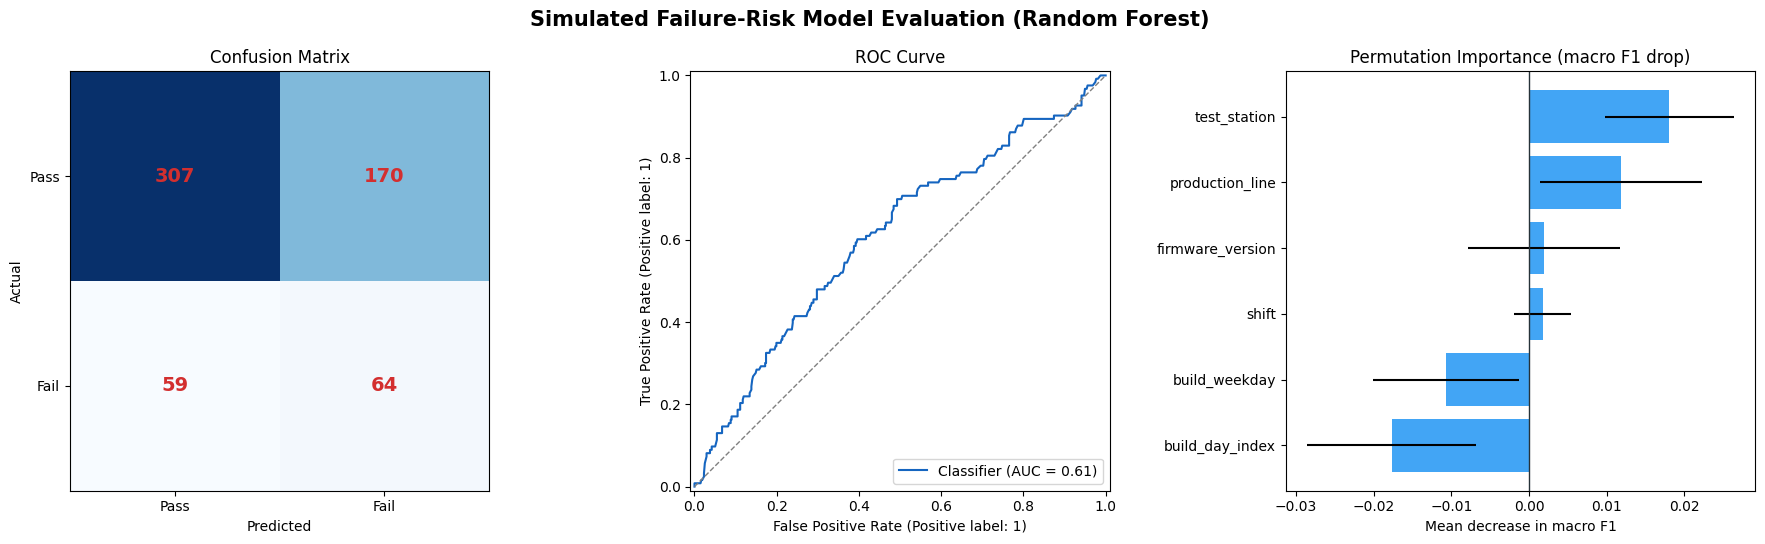

In [6]:
importance_result = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE
)

importance_df = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance_mean": importance_result.importances_mean,
        "importance_std": importance_result.importances_std
    })
    .sort_values("importance_mean", ascending=True)
)

display(
    importance_df.sort_values("importance_mean", ascending=False)
    .style.format({
        "importance_mean": "{:.4f}",
        "importance_std": "{:.4f}"
    })
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    f"Simulated Failure-Risk Model Evaluation ({best_model_name})",
    fontsize=15,
    fontweight="bold"
)

confusion = confusion_matrix(y_test, best_predictions)

axes[0].imshow(confusion, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticks([0, 1], ["Pass", "Fail"])
axes[0].set_yticks([0, 1], ["Pass", "Fail"])

for row in range(2):
    for column in range(2):
        axes[0].text(
            column,
            row,
            f"{confusion[row, column]}",
            ha="center",
            va="center",
            color="#D32F2F",
            fontsize=14,
            fontweight="bold"
        )

RocCurveDisplay.from_predictions(
    y_test,
    best_probabilities,
    ax=axes[1],
    color="#1565C0"
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_title("ROC Curve")

axes[2].barh(
    importance_df["feature"],
    importance_df["importance_mean"],
    xerr=importance_df["importance_std"],
    color="#42A5F5"
)
axes[2].axvline(0, color="#263238", linewidth=1)
axes[2].set_title("Permutation Importance (macro F1 drop)")
axes[2].set_xlabel("Mean decrease in macro F1")

plt.tight_layout()
plt.savefig(
    "failure_risk_model_evaluation.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [7]:
best_row = test_summary.loc[test_summary["Model"] == best_model_name].iloc[0]
top_features = importance_df.sort_values(
    "importance_mean", ascending=False
).head(3)

print("SIMULATED MODEL FINDINGS")
print(f"- Best model: {best_model_name}.")
print(
    f"- Test accuracy: {best_row['Accuracy']:.1%} "
    f"versus a {majority_class_accuracy:.1%} majority-class baseline."
)
print(f"- Test macro F1: {best_row['Macro F1']:.3f}.")
print(f"- Test ROC AUC: {best_row['ROC AUC']:.3f}.")
print("- Most influential process features by permutation importance:")

for _, row in top_features.iterrows():
    print(
        f"    {row['feature']}: "
        f"{row['importance_mean']:.4f} mean macro-F1 decrease"
    )

print(
    "- Measured test values were deliberately excluded as features, "
    "since the simulated pass/fail label was derived from them."
)
print(
    "- Interpretation: results are fictional and demonstrate modeling "
    "workflow only, not real manufacturing predictability."
)

SIMULATED MODEL FINDINGS
- Best model: Random Forest.
- Test accuracy: 61.8% versus a 79.5% majority-class baseline.
- Test macro F1: 0.543.
- Test ROC AUC: 0.609.
- Most influential process features by permutation importance:
    test_station: 0.0180 mean macro-F1 decrease
    production_line: 0.0118 mean macro-F1 decrease
    firmware_version: 0.0019 mean macro-F1 decrease
- Measured test values were deliberately excluded as features, since the simulated pass/fail label was derived from them.
- Interpretation: results are fictional and demonstrate modeling workflow only, not real manufacturing predictability.
